In [ ]:
import tensorflow as tf

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
  PHASE 1: Feature Extraction (Frozen ResNet50)
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 155s 867ms/step - accuracy: 0.6858 - loss: 0.6635 - val_accuracy: 0.5000 - val_loss: 0.7969 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 686ms/step - accuracy: 0.7339 - loss: 0.5796 - val_accuracy: 0.5000 - val_loss: 0.8221 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 689ms/step - accuracy: 0.7429 - loss: 0.5412 - val_accuracy: 0.5000 - val_loss: 0.7560 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 691ms/step - accuracy: 0.7471 - loss: 0.5194 - val_accuracy: 0.5000 - val_loss: 0.7871 - learning_rate: 1.0000e-04
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 687ms/step - accur

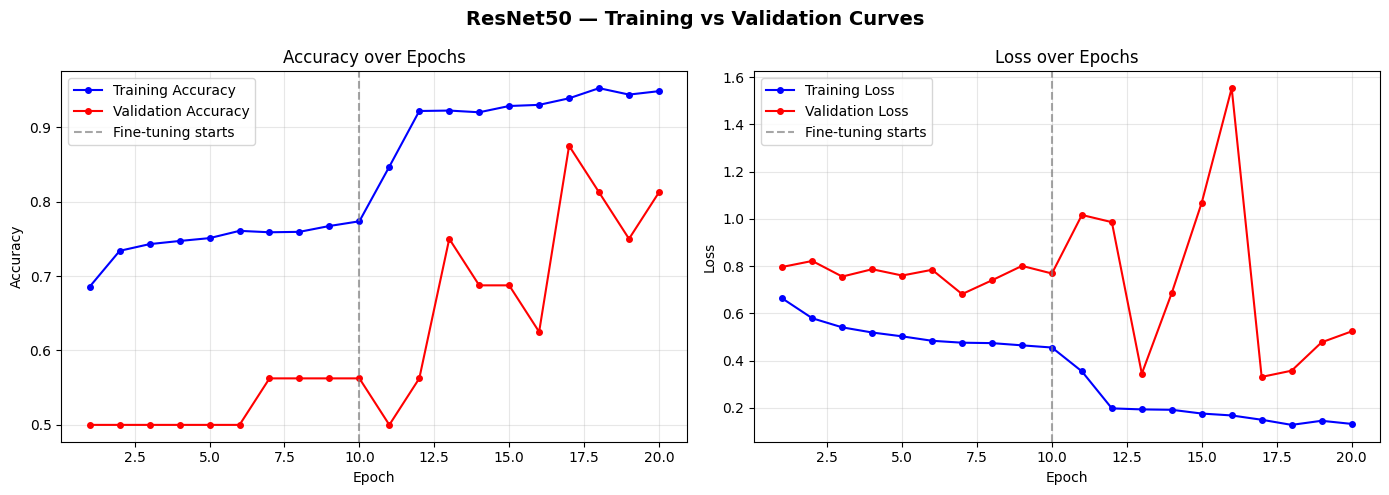

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 563ms/step

  ResNet50 — FINAL TEST RESULTS
Accuracy:  87.02%
Precision: 90.13%
Recall:    88.97%
F1 Score:  89.55%

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.82      0.84      0.83       234
   PNEUMONIA       0.90      0.89      0.90       390

    accuracy                           0.87       624
   macro avg       0.86      0.86      0.86       624
weighted avg       0.87      0.87      0.87       624



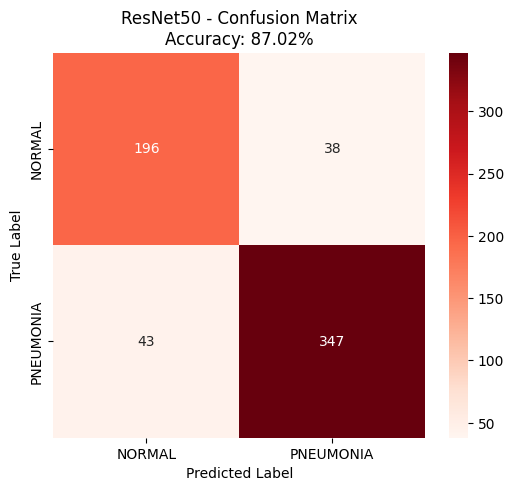

In [ ]:
import os
import numpy as np
import kagglehub
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, recall_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
DATA_DIR = os.path.join(path, "chest_xray")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1]
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "train"),
    target_size=(224, 224), batch_size=32, class_mode='binary'
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "val"),
    target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "test"),
    target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False
)

# ============================================
# PHASE 1: Feature Extraction
# ============================================
print("="*50)
print("  PHASE 1: Feature Extraction (Frozen ResNet50)")
print("="*50)

base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

model = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr1 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

history1 = model.fit(
    train_gen, epochs=10, validation_data=val_gen,
    callbacks=[early_stop1, reduce_lr1]
)

# ============================================
# PHASE 2: Fine-Tuning
# ============================================
print("\n" + "="*50)
print("  PHASE 2: Fine-Tuning (Unfrozen Top Layers)")
print("="*50)

base.trainable = True
for layer in base.layers[:140]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr2 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

history2 = model.fit(
    train_gen, epochs=10, validation_data=val_gen,
    callbacks=[early_stop2, reduce_lr2]
)

print(f"\nPhase 1 completed: {len(history1.history['loss'])} epochs")
print(f"Phase 2 completed: {len(history2.history['loss'])} epochs")


acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']
epochs = range(1, len(acc) + 1)
tune_start = len(history1.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ResNet50 — Training vs Validation Curves", fontsize=14, fontweight='bold')

axes[0].plot(epochs, acc, 'b-o', ms=4, label='Training Accuracy')
axes[0].plot(epochs, val_acc, 'r-o', ms=4, label='Validation Accuracy')
axes[0].axvline(tune_start, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning starts')
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, loss, 'b-o', ms=4, label='Training Loss')
axes[1].plot(epochs, val_loss, 'r-o', ms=4, label='Validation Loss')
axes[1].axvline(tune_start, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning starts')
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("resnet50_training_curves.png", dpi=150)
plt.show()


test_gen.reset()
y_prob = model.predict(test_gen)
y_pred = (y_prob > 0.5).astype(int)
y_true = test_gen.classes

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\n" + "="*50)
print("  ResNet50 — FINAL TEST RESULTS")
print("="*50)
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
plt.title(f"ResNet50 - Confusion Matrix\nAccuracy: {accuracy*100:.2f}%")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.savefig("resnet50_confusion.png", dpi=150)
plt.show()